<a href="https://colab.research.google.com/github/Botatopiece9/kpneumo-amr-prediction/blob/main/04_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

PROJECT_DIR = "/content/drive/MyDrive/kpneumo-amr-prediction"

table = pd.read_csv(f"{PROJECT_DIR}/gene_table_200.csv", dtype={"genome_id": str})
print(table.shape)
print(table["label"].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(200, 223)
label
Resistant      100
Susceptible    100
Name: count, dtype: int64


In [4]:
y = (table["label"] == "Resistant").astype(int)

not_genes = ["genome_id", "label", "mlst", "has_carbapenem_element"]
X = table.drop(columns=not_genes)

n_genomes = len(X)
times_seen = X.sum()
keep = (times_seen >= 2) & (times_seen < n_genomes)
X = X.loc[:, keep]

print("Genes before filtering:", len(times_seen))
print("Genes kept:", X.shape[1])

Genes before filtering: 219
Genes kept: 133


In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_rule = table["has_carbapenem_element"]

cm = confusion_matrix(y, y_rule)
tn, fp, fn, tp = cm.ravel()

print(cm)
print(f"Accuracy:    {accuracy_score(y, y_rule):.3f}")
print(f"Sensitivity: {tp / (tp + fn):.3f}")
print(f"Specificity: {tn / (tn + fp):.3f}")

[[ 71  29]
 [  0 100]]
Accuracy:    0.855
Sensitivity: 1.000
Specificity: 0.710


In [6]:
gene_cols = X.columns

false_alarm = (y == 0) & (y_rule == 1)
true_neg    = (y == 0) & (y_rule == 0)
true_pos    = (y == 1) & (y_rule == 1)

comparison = pd.DataFrame({
    "false_alarms": table.loc[false_alarm, gene_cols].mean(),
    "true_resistant": table.loc[true_pos, gene_cols].mean(),
    "true_susceptible": table.loc[true_neg, gene_cols].mean(),
})

comparison["diff"] = comparison["false_alarms"] - comparison["true_susceptible"]
print(comparison.sort_values("diff", ascending=False).head(10).round(2).to_string())
print("Number of false alarms:", false_alarm.sum())

                    false_alarms  true_resistant  true_susceptible  diff
parC_S80I                   0.59            0.86              0.14  0.45
gyrA_S83I                   0.48            0.68              0.08  0.40
gyrA_D87N                   0.38            0.24              0.01  0.37
sul1                        0.52            0.70              0.18  0.33
qacEdelta1                  0.45            0.69              0.17  0.28
nfsB_K130QfsTer5            0.24            0.09              0.00  0.24
ompK35_G208VfsTer5          0.24            0.10              0.00  0.24
blaCTX-M-15                 0.52            0.36              0.31  0.21
ompK35_E132K                0.21            0.00              0.00  0.21
dfrA12                      0.24            0.42              0.04  0.20
Number of false alarms: 29


In [7]:
prefixes = ("blaKPC", "blaNDM", "blaOXA-48", "blaOXA-181", "blaOXA-232",
            "blaOXA-244", "blaVIM", "blaIMP", "ompK")
carb_cols = [c for c in gene_cols if c.startswith(prefixes)]

print(comparison.loc[carb_cols, ["false_alarms", "true_resistant", "true_susceptible"]]
      .round(2).to_string())

                     false_alarms  true_resistant  true_susceptible
blaKPC-2                     0.03            0.42               0.0
blaKPC-3                     0.00            0.27               0.0
blaNDM-1                     0.00            0.11               0.0
blaNDM-4                     0.03            0.03               0.0
blaOXA-181                   0.03            0.06               0.0
blaOXA-48                    0.17            0.10               0.0
ompK35_A59GfsTer21           0.00            0.02               0.0
ompK35_E132K                 0.21            0.00               0.0
ompK35_E42RfsTer47           0.14            0.36               0.0
ompK35_F300LfsTer25          0.00            0.02               0.0
ompK35_G208VfsTer5           0.24            0.10               0.0
ompK35_G62AfsTer1            0.03            0.05               0.0
ompK35_I25KfsTer39           0.03            0.04               0.0
ompK35_N29TfsTer34           0.00            0.0

In [8]:
def report(y_true, y_pred, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"{name}")
    print(f"  Missed resistant (fn): {fn}   False alarms (fp): {fp}")
    print(f"  Accuracy:    {accuracy_score(y_true, y_pred):.3f}")
    print(f"  Sensitivity: {tp / (tp + fn):.3f}")
    print(f"  Specificity: {tn / (tn + fp):.3f}")
    print()

carbapenemase_cols = [c for c in carb_cols if c.startswith("bla")]
print("Carbapenemase genes:", carbapenemase_cols)
print()

y_rule2 = table[carbapenemase_cols].max(axis=1)

report(y, y_rule,  "Rule 1: any carbapenem element")
report(y, y_rule2, "Rule 2: carbapenemase gene only")

Carbapenemase genes: ['blaKPC-2', 'blaKPC-3', 'blaNDM-1', 'blaNDM-4', 'blaOXA-181', 'blaOXA-48']

Rule 1: any carbapenem element
  Missed resistant (fn): 0   False alarms (fp): 29
  Accuracy:    0.855
  Sensitivity: 1.000
  Specificity: 0.710

Rule 2: carbapenemase gene only
  Missed resistant (fn): 8   False alarms (fp): 8
  Accuracy:    0.920
  Sensitivity: 0.920
  Specificity: 0.920



In [9]:
missed = (y == 1) & (y_rule2 == 0)

for i, row in table.loc[missed].iterrows():
    genes = [g for g in gene_cols if row[g] == 1]
    print(row["genome_id"], genes)
    print()

573.14212 ['aac(3)-IIe', "aac(6')-Ib", 'blaCTX-M-15', 'blaOXA', 'blaSHV-28', 'dfrA14', 'fosA', 'gyrA_D87N', 'gyrA_S83I', 'nfsB_K130QfsTer5', 'ompK35_G208VfsTer5', 'ompK36_D135DGD', 'oqxA', 'oqxB19', 'parC_S80I']

573.5644 ['aadA1', 'aadA2', "aph(3'')-Ib", "aph(3')-Ia", 'aph(6)-Id', 'blaCMY-4', 'blaCTX-M-15', 'blaSHV-1', 'dfrA1', 'dfrA12', 'floR', 'fosA', 'gyrA_D87N', 'gyrA_S83F', 'mgrB_Q30Ter', 'mph(A)', 'mrx(A)', 'oqxA', 'oqxB5', 'parC_S80I', 'qacEdelta1', 'sul1', 'sul2', 'tet(A)']

573.21140 ["aac(6')-Ib-cr5", 'aadA1', 'aadA2', "aph(3'')-Ib", "aph(3')-VI", 'aph(6)-Id', 'armA', 'arr-2', 'blaOXA-1', 'blaSHV-28', 'catB3', 'cmlA5', 'dfrA1', 'dfrA12', 'dfrA14', 'fosA', 'gyrA_D87G', 'gyrA_S83Y', 'mph(E)', 'msr(E)', 'ompK36_D135DGD', 'oqxA', 'oqxB', 'parC_S80I', 'qacEdelta1', 'qnrB1', 'sul1', 'sul2']

573.7216 ["aph(3'')-Ib", 'aph(6)-Id', 'blaCTX-M-15', 'blaSHV-27', 'blaTEM-1', 'ble', 'dfrA14', 'fosA', 'gyrA_D87G', 'oqxA', 'oqxB', 'qnrB1', 'sul2', 'tet(A)']

573.12783 ["aac(6')-Ib", 'aadA1'

In [10]:
print(table["mlst"].value_counts(dropna=False).head(15).to_string())
print("Number of different sequence types:", table["mlst"].nunique())

mlst
MLST.klebsiella.258    24
MLST.klebsiella.307    19
MLST.klebsiella.512    16
MLST.klebsiella.15     14
MLST.klebsiella.11     11
MLST.klebsiella.101     7
MLST.klebsiella.37      6
MLST.klebsiella.16      6
MLST.klebsiella.45      6
MLST.klebsiella.656     5
MLST.klebsiella.147     4
MLST.klebsiella.405     4
MLST.klebsiella.14      4
MLST.klebsiella.17      3
MLST.klebsiella.34      2
Number of different sequence types: 75


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_predict

groups = table["mlst"].fillna("unknown_" + table["genome_id"])

model = LogisticRegression(max_iter=1000)

random_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pred_random = cross_val_predict(model, X, y, cv=random_cv)

lineage_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
pred_lineage = cross_val_predict(model, X, y, cv=lineage_cv, groups=groups)

report(y, y_rule2, "Rule 2: carbapenemase gene only")
report(y, pred_random, "Logistic regression, random split")
report(y, pred_lineage, "Logistic regression, lineage split")

Rule 2: carbapenemase gene only
  Missed resistant (fn): 8   False alarms (fp): 8
  Accuracy:    0.920
  Sensitivity: 0.920
  Specificity: 0.920

Logistic regression, random split
  Missed resistant (fn): 14   False alarms (fp): 13
  Accuracy:    0.865
  Sensitivity: 0.860
  Specificity: 0.870

Logistic regression, lineage split
  Missed resistant (fn): 26   False alarms (fp): 8
  Accuracy:    0.830
  Sensitivity: 0.740
  Specificity: 0.920



In [12]:
def any_of(prefixes, must_contain=None):
    cols = [c for c in table.columns if c.startswith(prefixes)]
    if must_contain:
        cols = [c for c in cols if any(s in c for s in must_contain)]
    if not cols:
        return pd.Series(0, index=table.index)
    return table[cols].max(axis=1)

X_mech = pd.DataFrame({
    "KPC":            any_of(("blaKPC",)),
    "NDM":            any_of(("blaNDM",)),
    "OXA48_like":     any_of(("blaOXA-48", "blaOXA-181", "blaOXA-232", "blaOXA-244")),
    "VIM_IMP":        any_of(("blaVIM", "blaIMP")),
    "CTX_M":          any_of(("blaCTX-M",)),
    "AmpC":           any_of(("blaCMY", "blaDHA")),
    "ompK35_broken":  any_of(("ompK35_",), must_contain=("fs", "Ter")),
    "ompK36_altered": any_of(("ompK36_",)),
})

print(X_mech.mean().round(2).to_string())
print()

pred_mech_random = cross_val_predict(model, X_mech, y, cv=random_cv)
pred_mech_lineage = cross_val_predict(model, X_mech, y, cv=lineage_cv, groups=groups)

report(y, pred_mech_random, "Mechanism model, random split")
report(y, pred_mech_lineage, "Mechanism model, lineage split")

KPC               0.36
NDM               0.08
OXA48_like        0.12
VIM_IMP           0.00
CTX_M             0.42
AmpC              0.03
ompK35_broken     0.47
ompK36_altered    0.32

Mechanism model, random split
  Missed resistant (fn): 7   False alarms (fp): 6
  Accuracy:    0.935
  Sensitivity: 0.930
  Specificity: 0.940

Mechanism model, lineage split
  Missed resistant (fn): 8   False alarms (fp): 6
  Accuracy:    0.930
  Sensitivity: 0.920
  Specificity: 0.940



In [13]:
model.fit(X_mech, y)

weights = pd.Series(model.coef_[0], index=X_mech.columns).sort_values(ascending=False)
print(weights.round(2).to_string())
print("Intercept:", round(model.intercept_[0], 2))

KPC               3.77
NDM               2.23
ompK36_altered    1.68
OXA48_like        1.58
ompK35_broken     1.00
VIM_IMP           0.75
AmpC              0.51
CTX_M             0.23
Intercept: -2.57


In [14]:
results = pd.DataFrame([
    ["Rule 1: any carbapenem element", "none", y_rule],
    ["Rule 2: carbapenemase gene only", "none", y_rule2],
    ["Gene-variant model", "random", pred_random],
    ["Gene-variant model", "lineage", pred_lineage],
    ["Mechanism model", "random", pred_mech_random],
    ["Mechanism model", "lineage", pred_mech_lineage],
], columns=["approach", "split", "pred"])

rows = []
for _, r in results.iterrows():
    tn, fp, fn, tp = confusion_matrix(y, r["pred"]).ravel()
    rows.append({"approach": r["approach"], "split": r["split"],
                 "sensitivity": round(tp / (tp + fn), 3),
                 "specificity": round(tn / (tn + fp), 3),
                 "accuracy": round((tp + tn) / len(y), 3)})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(f"{PROJECT_DIR}/results_summary.csv", index=False)

                       approach   split  sensitivity  specificity  accuracy
 Rule 1: any carbapenem element    none         1.00         0.71     0.855
Rule 2: carbapenemase gene only    none         0.92         0.92     0.920
             Gene-variant model  random         0.86         0.87     0.865
             Gene-variant model lineage         0.74         0.92     0.830
                Mechanism model  random         0.93         0.94     0.935
                Mechanism model lineage         0.92         0.94     0.930


In [23]:
import os
import matplotlib.pyplot as plt

FIG_DIR = f"{PROJECT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

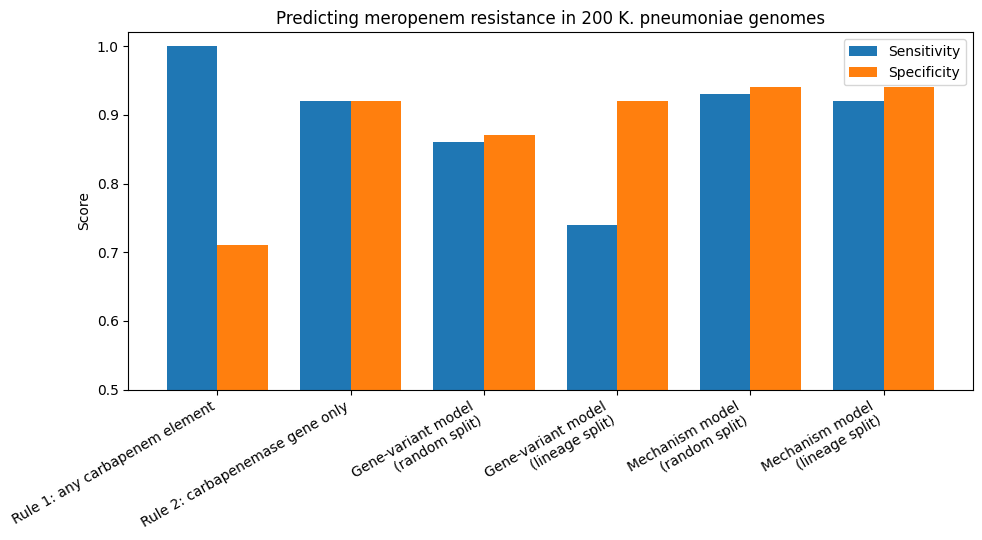

In [24]:
labels = [a if s == "none" else f"{a}\n({s} split)"
          for a, s in zip(summary["approach"], summary["split"])]

x = np.arange(len(summary))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - width/2, summary["sensitivity"], width, label="Sensitivity")
ax.bar(x + width/2, summary["specificity"], width, label="Specificity")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Score")
ax.set_title("Predicting meropenem resistance in 200 K. pneumoniae genomes")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/model_comparison.png", dpi=200)
plt.show()

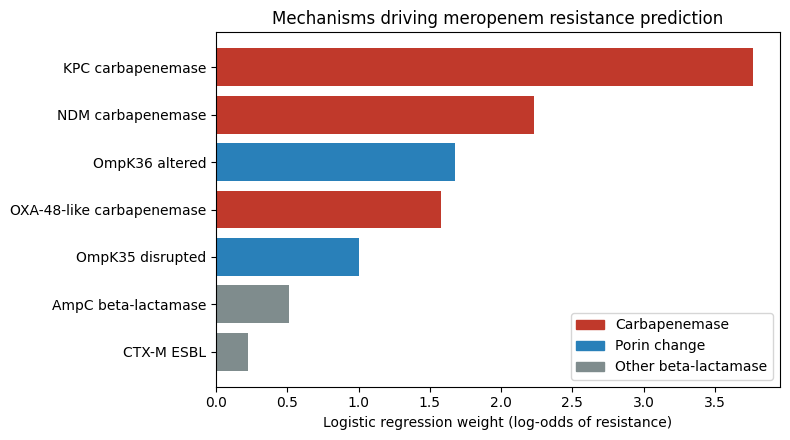

In [31]:
nice_names = {
    "KPC": "KPC carbapenemase",
    "NDM": "NDM carbapenemase",
    "OXA48_like": "OXA-48-like carbapenemase",
    "ompK36_altered": "OmpK36 altered",
    "ompK35_broken": "OmpK35 disrupted",
    "AmpC": "AmpC beta-lactamase",
    "CTX_M": "CTX-M ESBL",
}

plot_weights = weights.drop("VIM_IMP").sort_values()
plot_weights.index = [nice_names[n] for n in plot_weights.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
categories = {
    "KPC carbapenemase": "Carbapenemase",
    "NDM carbapenemase": "Carbapenemase",
    "OXA-48-like carbapenemase": "Carbapenemase",
    "OmpK36 altered": "Porin change",
    "OmpK35 disrupted": "Porin change",
    "AmpC beta-lactamase": "Other beta-lactamase",
    "CTX-M ESBL": "Other beta-lactamase",
}
colors = {"Carbapenemase": "#c0392b", "Porin change": "#2980b9", "Other beta-lactamase": "#7f8c8d"}


bar_colors = [colors[categories[n]] for n in plot_weights.index]
ax.barh(plot_weights.index, plot_weights.values, color=bar_colors)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in colors.items()], loc="lower right")
ax.set_xlabel("Logistic regression weight (log-odds of resistance)")
ax.set_title("Mechanisms driving meropenem resistance prediction")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/mechanism_weights.png", dpi=200)
plt.show()

In [29]:
drive.flush_and_unmount()
print("All files uploaded to Drive")

Drive not mounted, so nothing to flush and unmount.
All files uploaded to Drive
